# TDSC-ABUS 2023 — dataset visualization

A tour of the data this project classifies: what is in it, how balanced it is, what the
tumors look like in 2D and 3D, and which quantitative features separate malignant from
benign lesions.

1. [Loading the dataset](#1-loading-the-dataset)
2. [Class balance](#2-class-balance)
3. [Sample tumors](#3-sample-tumors)
4. [Tumor shape in 3D](#4-tumor-shape-in-3d)
5. [Statistics for classification](#5-statistics-for-classification)

Every feature used below comes from `abus_classification.features`, so the numbers here are
the same ones the classifiers are trained on.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import trimesh
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sys.path.append("..")

from tdsc_abus2023_pytorch import TDSC, TDSCTumors, DataSplits

from abus_classification.features import radiology as rad
from abus_classification.features import texture as tex
from abus_classification.utils.mesh import get_mesh_from_3d_mask

print(f"numpy {np.__version__} · pandas {pd.__version__} · trimesh {trimesh.__version__}")

numpy 2.5.3 · pandas 3.0.5 · trimesh 5.1.0


### Plot styling

One palette for the whole notebook. Malignant and benign are *identities*, not magnitudes,
so they get two categorical hues; everything else (grid, axes, labels) stays recessive ink
so the data carries the color.

In [2]:
# --- palette -------------------------------------------------------------
SURFACE   = "#fcfcfb"   # chart surface
INK       = "#0b0b0b"   # primary text
INK_2     = "#52514e"   # secondary text
MUTED     = "#898781"   # axis labels / ticks
GRID      = "#e1e0d9"   # hairline gridlines
AXIS      = "#c3c2b7"   # baseline

MALIGNANT = "#eb6834"   # categorical slot 2 (orange)
BENIGN    = "#2a78d6"   # categorical slot 1 (blue)

CLASS_COLOR = {0: MALIGNANT, 1: BENIGN}
CLASS_NAME  = {0: "Malignant", 1: "Benign"}

# Grayscale for ultrasound; NaN padding renders as page, not as black.
GRAY = mpl.colormaps["gray"].with_extremes(bad=SURFACE)

# Diverging pair for correlations: warm <-> cool with a neutral midpoint.
DIVERGING = mpl.colors.LinearSegmentedColormap.from_list(
    "blue_gray_red", [BENIGN, "#f0efec", "#d03b3b"]
)

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         10,
    "text.color":        INK,
    "axes.labelcolor":   INK_2,
    "axes.titlecolor":   INK,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.titlelocation": "left",
    "axes.titlepad":     10,
    "axes.labelsize":    9.5,
    "axes.edgecolor":    AXIS,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "grid.linestyle":    "-",      # never dashed
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.dpi":        110,
})


def fig_title(fig, title, subtitle=None, x=0.008):
    """Figure title + subtitle, spaced in inches so they never collide.

    Returns the `rect` top for tight_layout.
    """
    h = fig.get_figheight()
    fig.suptitle(title, x=x, y=1 - 0.26 / h, ha="left", va="top",
                 fontsize=13, fontweight="bold", color=INK)
    if subtitle:
        fig.text(x, 1 - 0.58 / h, subtitle, ha="left", va="top",
                 fontsize=9.5, color=INK_2)
    return 1 - (0.92 if subtitle else 0.62) / h


def value_grid(ax, axis="y"):
    """Recessive hairline grid on the value axis only, behind the marks."""
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)

## 1. Loading the dataset

`TDSC` yields whole ABUS volumes; `TDSCTumors` yields the same cases cropped to the
annotated tumor bounding box. Almost everything below uses the cropped view — a full volume
is ~865x608x330 voxels, of which the lesion is a small fraction.

> **Note on `download=True`:** the package calls `DatasetDownloader.download_dataset()`
> unconditionally, so passing it on every run re-downloads ~15 GB. The helper below only
> asks for a download when the split directory is actually missing.

In [3]:
DATA_ROOT = Path("../data/tdsc")
SPLITS = [DataSplits.TRAIN, DataSplits.VALIDATION, DataSplits.TEST]


def load_split(split, cls=TDSCTumors):
    """Load one split, downloading only if it is not already on disk."""
    missing = not (DATA_ROOT / str(split)).exists()
    if missing:
        print(f"{split} not found — downloading (this is several GB)...")
    return cls(path=str(DATA_ROOT), split=split, download=missing)


tumors = {s: load_split(s, TDSCTumors) for s in SPLITS}
volumes = {s: load_split(s, TDSC) for s in SPLITS}

for s in SPLITS:
    print(f"{str(s):11s} {len(tumors[s]):3d} cases")
print(f"{'TOTAL':11s} {sum(len(d) for d in tumors.values()):3d} cases")

Train       100 cases
Validation   30 cases
Test         70 cases
TOTAL       200 cases


### What one case contains

Each case is a volume, a binary lesion mask of the same shape, and a label
(`0` = malignant, `1` = benign). The array axes follow the package's own
`ViewTransposeConfig`: axis 0 is **axial**, axis 1 **coronal**, axis 2 **sagittal**.

In [4]:
AXIS_NAME = {0: "Axial", 1: "Coronal", 2: "Sagittal"}

full_vol, full_mask, label, bbox = volumes[DataSplits.TRAIN][0]
crop_vol, crop_mask, label = tumors[DataSplits.TRAIN][0]

rows = [
    ("Full volume",   full_vol.shape,  full_vol.dtype,  f"{full_vol.size/1e6:.1f} M voxels"),
    ("Full mask",     full_mask.shape, full_mask.dtype, f"{int(full_mask.sum()):,} lesion voxels"),
    ("Cropped volume", crop_vol.shape,  crop_vol.dtype,  f"{crop_vol.size/1e6:.2f} M voxels"),
    ("Cropped mask",   crop_mask.shape, crop_mask.dtype, f"{int(crop_mask.sum()):,} lesion voxels"),
]
overview = pd.DataFrame(rows, columns=["array", "shape", "dtype", "size"])
print(f"case 0 — label {label} ({CLASS_NAME[label]})")
print(f"lesion occupies {100*full_mask.sum()/full_mask.size:.3f}% of the full volume")
overview

case 0 — label 0 (Malignant)
lesion occupies 0.139% of the full volume


,array,shape,dtype,size
0,Full volume,"(865, 608, 330)",uint8,173.6 M voxels
1,Full mask,"(865, 608, 330)",uint8,"241,350 lesion voxels"
2,Cropped volume,"(114, 256, 35)",uint8,1.02 M voxels
3,Cropped mask,"(114, 256, 35)",uint8,"241,072 lesion voxels"


## 2. Class balance

The label is the thing being predicted, so its distribution sets the floor for any accuracy
claim: a classifier that always answers "malignant" already scores whatever the malignant
share is. Counts come from each split's `labels.csv`, so this cell reads no image data.

In [5]:
labels = pd.concat(
    [d.metadata[["label"]].assign(split=str(s)) for s, d in tumors.items()]
).reset_index()
labels["class"] = labels["label"].map({"M": "Malignant", "B": "Benign"})

balance = (
    labels.pivot_table(index="split", columns="class", values="case_id", aggfunc="count")
    .reindex([str(s) for s in SPLITS])
    .fillna(0).astype(int)
)
balance["Total"] = balance.sum(axis=1)
balance["Malignant %"] = (100 * balance["Malignant"] / balance["Total"]).round(1)
balance.loc["All"] = balance.sum()
balance.loc["All", "Malignant %"] = round(100 * balance.loc["All", "Malignant"] / balance.loc["All", "Total"], 1)

counts = ["Malignant", "Benign", "Total"]
balance[counts] = balance[counts].astype(int)   # summing in a float column promoted these
balance

class,Benign,Malignant,Total,Malignant %
split,,,,
Train,42,58,100,58.0
Validation,13,17,30,56.7
Test,30,40,70,57.1
All,85,115,200,57.5


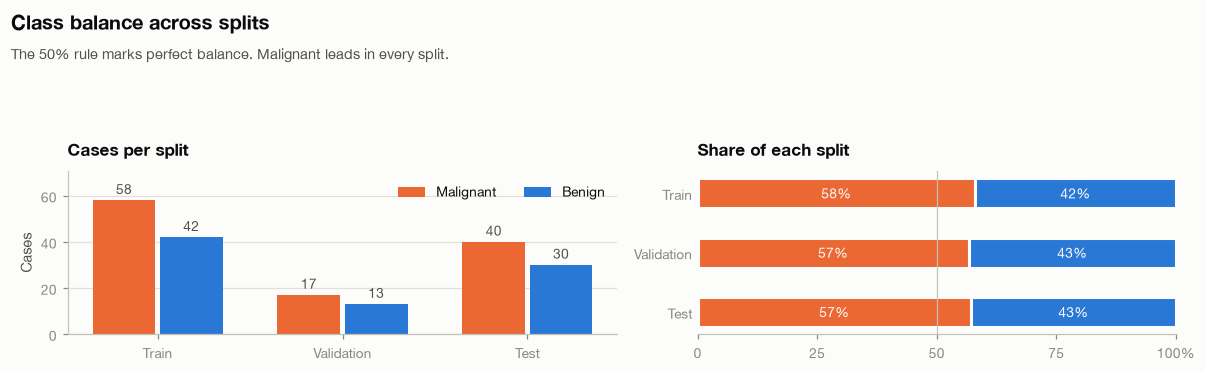

In [6]:
splits = [str(s) for s in SPLITS]
mal = balance.loc[splits, "Malignant"].to_numpy().astype(int)
ben = balance.loc[splits, "Benign"].to_numpy().astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})

# --- counts: grouped columns, direct-labelled ---------------------------
x = np.arange(len(splits))
w = 0.34
ax1.bar(x - w/2 - 0.012, mal, w, color=MALIGNANT, label="Malignant")
ax1.bar(x + w/2 + 0.012, ben, w, color=BENIGN, label="Benign")
for xi, (m, b) in enumerate(zip(mal, ben)):
    ax1.text(xi - w/2 - 0.012, m + 1.5, str(m), ha="center", va="bottom", fontsize=9, color=INK_2)
    ax1.text(xi + w/2 + 0.012, b + 1.5, str(b), ha="center", va="bottom", fontsize=9, color=INK_2)
ax1.set_xticks(x, splits)
ax1.set_ylabel("Cases")
ax1.set_ylim(0, max(mal.max(), ben.max()) * 1.22)
ax1.set_title("Cases per split")
value_grid(ax1)
ax1.legend(loc="upper right", ncols=2)

# --- proportion: 100% stacked bars, 2px surface gap between segments -----
total = mal + ben
mal_pct, ben_pct = 100 * mal / total, 100 * ben / total
y = np.arange(len(splits))[::-1]
ax2.barh(y, mal_pct, 0.5, color=MALIGNANT, edgecolor=SURFACE, linewidth=2)
ax2.barh(y, ben_pct, 0.5, left=mal_pct, color=BENIGN, edgecolor=SURFACE, linewidth=2)
for yi, (mp, bp) in enumerate(zip(mal_pct[::-1], ben_pct[::-1])):
    ax2.text(mp / 2, y[::-1][yi], f"{mp:.0f}%", ha="center", va="center", color=SURFACE, fontsize=9)
    ax2.text(mp + bp / 2, y[::-1][yi], f"{bp:.0f}%", ha="center", va="center", color=SURFACE, fontsize=9)
ax2.axvline(50, color=AXIS, linewidth=0.8, zorder=3)
ax2.set_yticks(y, splits)
ax2.set_xlim(0, 100)
ax2.set_xticks([0, 25, 50, 75, 100], ["0", "25", "50", "75", "100%"])
ax2.set_title("Share of each split")
ax2.spines["left"].set_visible(False)
ax2.tick_params(axis="y", length=0)

top = fig_title(fig, "Class balance across splits",
                "The 50% rule marks perfect balance. Malignant leads in every split.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

## 3. Sample tumors

`len_x` is the smallest bounding-box side for all 200 cases (mean 32 voxels, against 169 and
128), so the sagittal plane — slicing along axis 2 — always shows the widest face of the
lesion. Each panel below is that plane through the tumor's centre of mass, with the
annotated mask outlined in the class color.

In [7]:
def pad_to(img, shape, fill=np.nan):
    """Centre `img` on a canvas of `shape` so panels share one scale.

    The default NaN fill renders as page colour rather than black, so the
    padding needed to line panels up stays invisible.
    """
    out = np.full(shape, fill, dtype=float)
    h, w = img.shape
    top, left = (shape[0] - h) // 2, (shape[1] - w) // 2
    out[top:top + h, left:left + w] = img
    return out


def centroid_slice(vol, mask, axis=2):
    """The slice through the mask's centre of mass along `axis`."""
    idx = int(round(np.argwhere(mask > 0).mean(axis=0)[axis]))
    sl = [slice(None)] * 3
    sl[axis] = idx
    return vol[tuple(sl)], mask[tuple(sl)], idx


def show_tumor(ax, vol, mask, axis=2, color=None, title=None, subtitle=None, canvas=None):
    img, msk, idx = centroid_slice(vol, mask, axis)
    if canvas is not None:
        img, msk = pad_to(img, canvas), pad_to(msk, canvas, fill=0)
    ax.imshow(img, cmap=GRAY, vmin=0, vmax=255, aspect="equal", interpolation="nearest")
    if msk.any():
        ax.contour(msk, levels=[0.5], colors=[color or MALIGNANT], linewidths=1.6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    if title:
        ax.set_title(title, fontsize=9.5, pad=4)
    if subtitle:
        ax.text(0.5, -0.04, subtitle, transform=ax.transAxes, ha="center", va="top",
                fontsize=8, color=MUTED)
    return idx

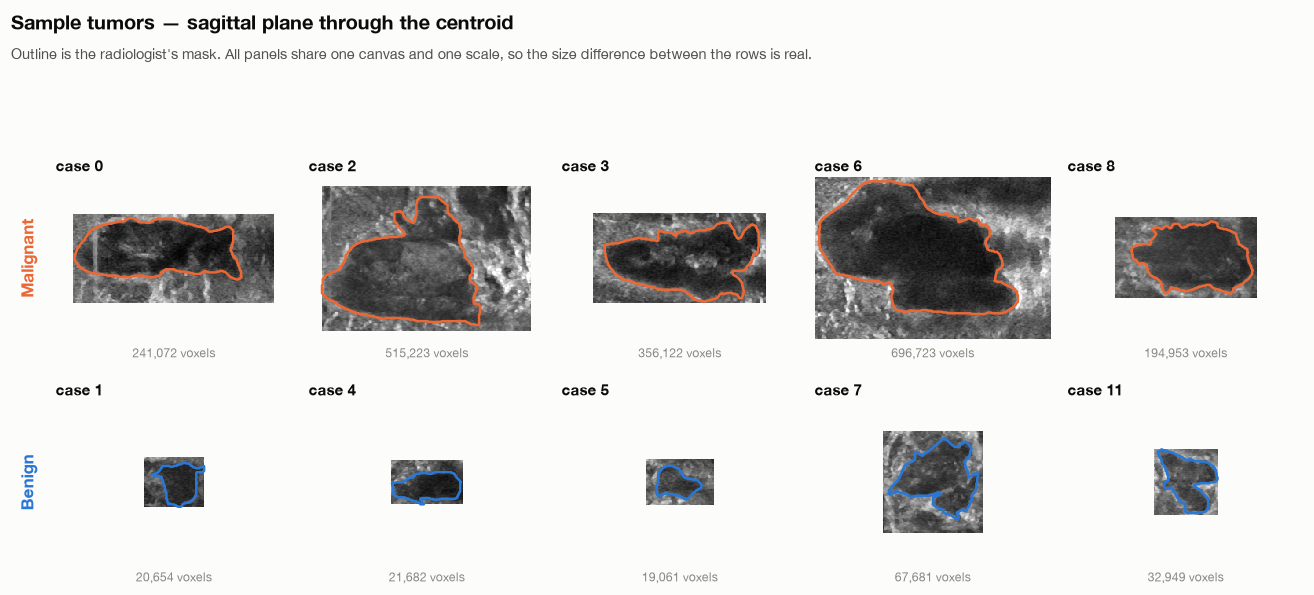

In [8]:
train = tumors[DataSplits.TRAIN]
train_labels = train.metadata["label"].to_numpy()
mal_idx = np.where(train_labels == "M")[0][:5]
ben_idx = np.where(train_labels == "B")[0][:5]

samples = [(int(i), 0) for i in mal_idx] + [(int(i), 1) for i in ben_idx]
loaded = {i: train[i] for i, _ in samples}

# One canvas for every panel, so the grid lines up and sizes are comparable.
canvas = np.max([centroid_slice(v, m, 2)[0].shape for v, m, _ in loaded.values()], axis=0)

panel_w = 12 / 5
fig, axes = plt.subplots(2, 5, figsize=(12, 2 * panel_w * canvas[0] / canvas[1] + 2.5))
for n, (i, cls) in enumerate(samples):
    vol, msk, lab = loaded[i]
    ax = axes[n // 5, n % 5]
    show_tumor(ax, vol, msk, axis=2, color=CLASS_COLOR[cls], canvas=tuple(canvas),
               title=f"case {train.metadata.index[i]}",
               subtitle=f"{int(msk.sum()):,} voxels")
for row, cls in enumerate((0, 1)):
    axes[row, 0].set_ylabel(CLASS_NAME[cls], fontsize=11, fontweight="bold",
                            color=CLASS_COLOR[cls], labelpad=12)

top = fig_title(fig, "Sample tumors — sagittal plane through the centroid",
                "Outline is the radiologist's mask. All panels share one canvas and one scale, "
                "so the size difference between the rows is real.")
fig.tight_layout(rect=[0, 0, 1, top], h_pad=3.2)
plt.show()

### One tumor in three planes

The same lesion sliced along each axis, plus a run of consecutive sagittal slices showing how
the cross-section grows and shrinks through the lesion.

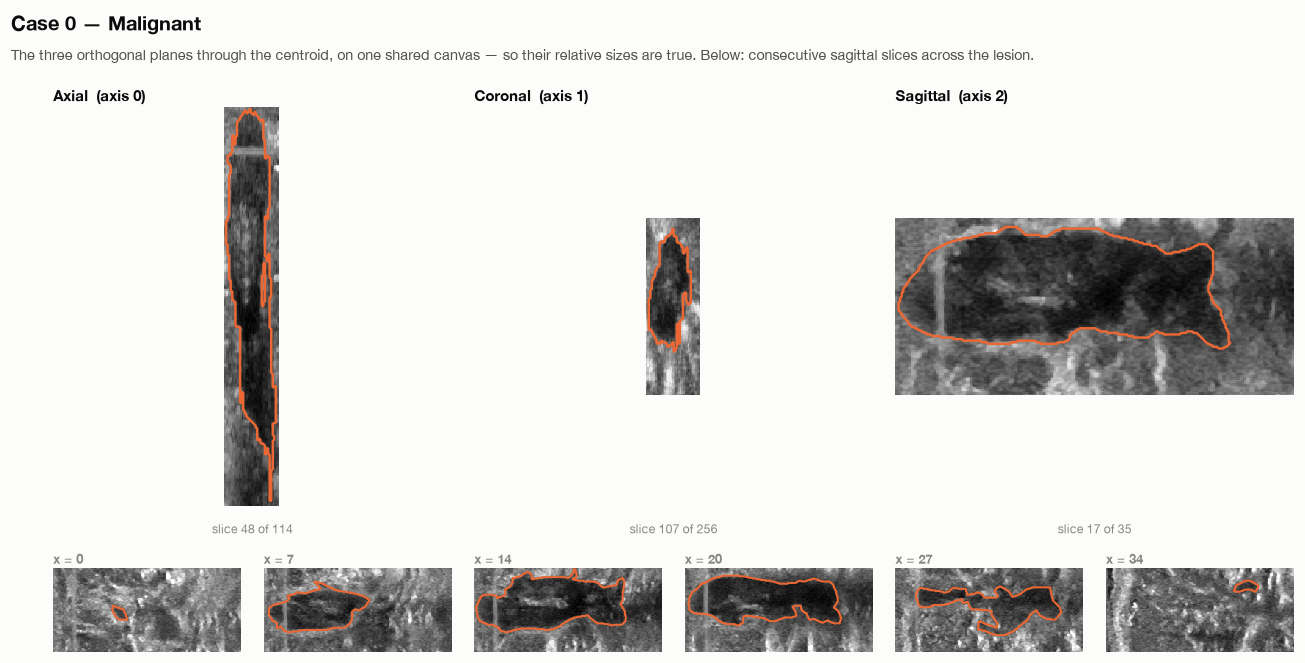

In [9]:
case = 0
vol, msk, lab = train[case]
color = CLASS_COLOR[lab]

centre = np.argwhere(msk > 0).mean(axis=0).round().astype(int)
plane_canvas = tuple(np.max([centroid_slice(vol, msk, a)[0].shape for a in range(3)], axis=0))

plane_h = (12 / 3) * plane_canvas[0] / plane_canvas[1]
strip_h = (12 / 6) * vol.shape[0] / vol.shape[1]
fig_h = plane_h + strip_h + 1.6
fig = plt.figure(figsize=(12, fig_h))
gs = fig.add_gridspec(2, 6, height_ratios=[plane_h, strip_h], hspace=0.16, wspace=0.12,
                      left=0.04, right=0.98,
                      top=1 - 1.0 / fig_h, bottom=0.35 / fig_h)

for axis in range(3):
    ax = fig.add_subplot(gs[0, axis * 2:(axis + 1) * 2])
    show_tumor(ax, vol, msk, axis=axis, color=color, canvas=plane_canvas,
               title=f"{AXIS_NAME[axis]}  (axis {axis})",
               subtitle=f"slice {centre[axis]} of {vol.shape[axis]}")

positions = np.linspace(0, vol.shape[2] - 1, 6).round().astype(int)
for col, k in enumerate(positions):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(vol[:, :, k], cmap=GRAY, vmin=0, vmax=255, interpolation="nearest")
    if (msk[:, :, k] > 0).any():
        ax.contour(msk[:, :, k], levels=[0.5], colors=[color], linewidths=1.3)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"x = {k}", fontsize=8.5, color=MUTED, pad=3)

fig_title(fig, f"Case {train.metadata.index[case]} — {CLASS_NAME[lab]}",
          "The three orthogonal planes through the centroid, on one shared canvas — so their "
          "relative sizes are true. Below: consecutive sagittal slices across the lesion.")
plt.show()

## 4. Tumor shape in 3D

`abus_classification.utils.mesh.get_mesh_from_3d_mask` runs marching cubes over the binary
mask and returns a `trimesh.Trimesh`.

Two settings matter, and both show up as a *negative* mesh volume when they are wrong —
trimesh cannot orient the faces of an open surface, so `fix_normals()` leaves the winding
inside-out and `mesh.volume` comes back signed the wrong way.

**1. Pad the mask.** `TDSCTumors` crops exactly to the bounding box, so the lesion touches the
crop faces and marching cubes leaves the surface open. Two zero voxels of padding close it.

**2. Turn the preprocessing off.** `preprocess_binary_mask` applies a morphological closing
that pinches thin structures into non-manifold geometry. On these masks it breaks 8 of the
200 cases — all of them large, high-genus malignant lesions — and no amount of extra padding
recovers them. The masks are hand-drawn annotations that are already clean, so there is
nothing for the closing to fix:

| `get_mesh_from_3d_mask` on a mask padded by 2 | not watertight | negative volume |
|---|---|---|
| `preprocess=True` (the default) | 8 / 200 | 8 / 200 |
| `preprocess=False` | **0 / 200** | **0 / 200** |

With `preprocess=False` the mesh volume lands within 0.2% of the raw voxel count across all
200 cases (ratio 0.998 ± 0.002), which is the accuracy you would expect from marching cubes.

In [10]:
def tumor_mesh(mask, pad=2, preprocess=False):
    """Watertight trimesh surface for a cropped lesion mask."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return get_mesh_from_3d_mask(np.pad((mask > 0).astype(np.uint8), pad),
                                     preprocess=preprocess)


# Measured, not asserted — case 2 is one of the eight the closing breaks.
_probe, _mask, _ = train[2]
rows = []
for name, pad, prep in [("raw crop", 0, True), ("padded by 2", 2, True), ("padded by 2", 2, False)]:
    g = tumor_mesh(_mask, pad=pad, preprocess=prep)
    rows.append({"mask": name, "preprocess": prep, "watertight": g.is_watertight,
                 "mesh volume": round(g.volume), "mask voxels": int((_mask > 0).sum())})
pd.DataFrame(rows)

,mask,preprocess,watertight,mesh volume,mask voxels
0,raw crop,True,False,-523825,515223
1,padded by 2,True,False,-530735,515223
2,padded by 2,False,True,514835,515223


In [11]:
def render_mesh(ax, mesh, color, title, subtitle=None):
    tri = mesh.vertices[mesh.faces]
    coll = Poly3DCollection(tri, alpha=0.85, facecolor=color, edgecolor="none")
    coll.set_zsort("average")
    ax.add_collection3d(coll)

    lo, hi = mesh.vertices.min(axis=0), mesh.vertices.max(axis=0)
    extent = hi - lo
    pad = extent.max() * 0.04
    ax.set_xlim(lo[0] - pad, hi[0] + pad)
    ax.set_ylim(lo[1] - pad, hi[1] + pad)
    ax.set_zlim(lo[2] - pad, hi[2] + pad)
    ax.set_box_aspect(extent / extent.max())   # true proportions, not a forced cube
    ax.view_init(elev=24, azim=-62)

    ax.set_xlabel("z (axial)", labelpad=-8, fontsize=8, color=MUTED)
    ax.set_ylabel("y (coronal)", labelpad=-8, fontsize=8, color=MUTED)
    ax.set_zlabel("x (sagittal)", labelpad=-8, fontsize=8, color=MUTED)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.tick_params(length=0)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
        pane.pane.set_facecolor(SURFACE)
        pane.pane.set_edgecolor(GRID)
        pane._axinfo["grid"]["color"] = GRID
        pane._axinfo["grid"]["linewidth"] = 0.6
    ax.set_title(title, fontsize=10.5, pad=-2, color=INK)
    if subtitle:
        ax.text2D(0.5, -0.02, subtitle, transform=ax.transAxes, ha="center", va="top",
                  fontsize=8.5, color=MUTED)

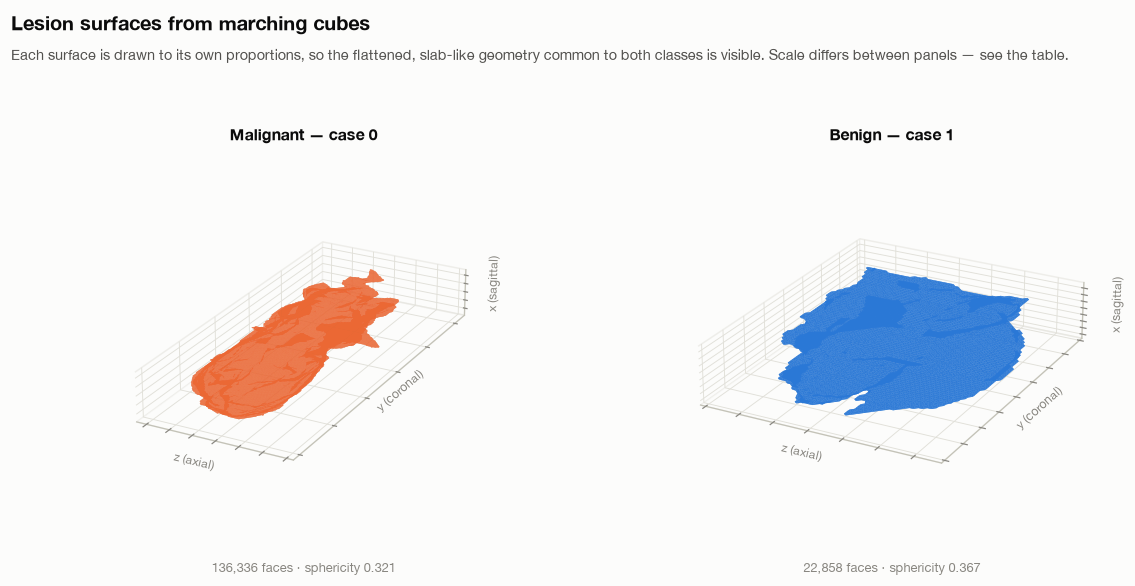

,class,"extent (z, y, x)",mask voxels,mesh volume,surface area,area / volume,watertight,faces
case,,,,,,,,
0,Malignant,"(114, 256, 35)",241072,240831,58310,0.2421,True,136336
1,Benign,"(63, 77, 15)",20654,20565,9933,0.4830,True,22858


In [12]:
picks = [(int(mal_idx[0]), 0), (int(ben_idx[0]), 1)]

fig = plt.figure(figsize=(11, 5.4))
stats = []
for n, (i, cls) in enumerate(picks):
    v, m, lb = train[i]
    mesh = tumor_mesh(m)
    ax = fig.add_subplot(1, 2, n + 1, projection="3d")
    render_mesh(
        ax, mesh, CLASS_COLOR[cls],
        f"{CLASS_NAME[cls]} — case {train.metadata.index[i]}",
        f"{len(mesh.faces):,} faces · sphericity {rad.sphericity(np.pad((m>0).astype(np.uint8), 2)):.3f}",
    )
    extent = np.ptp(np.argwhere(m > 0), axis=0) + 1
    stats.append({
        "case": train.metadata.index[i],
        "class": CLASS_NAME[cls],
        "extent (z, y, x)": tuple(int(e) for e in extent),
        "mask voxels": int((m > 0).sum()),
        "mesh volume": round(mesh.volume),
        "surface area": round(mesh.area),
        "area / volume": round(mesh.area / mesh.volume, 4),
        "watertight": mesh.is_watertight,
        "faces": len(mesh.faces),
    })

top = fig_title(fig, "Lesion surfaces from marching cubes",
                "Each surface is drawn to its own proportions, so the flattened, slab-like geometry "
                "common to both classes is visible. Scale differs between panels — see the table.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

pd.DataFrame(stats).set_index("case")

`mesh.show()` opens the same surface in trimesh's interactive viewer if you want to rotate it
(it needs a windowing backend, so it is left out of the executed notebook).

## 5. Statistics for classification

The features below are exactly the ones implemented in `abus_classification.features` —
shape, intensity and texture descriptors of the kind used in the ABUS radiomics literature.
They are computed once for all 200 cases and cached to CSV.

| Group | Feature | Source |
|---|---|---|
| Shape | `volume_voxels`, `mesh_volume`, `surface_area`, `area_per_volume` | `utils.mesh` + trimesh |
| Shape | `sphericity` | `features.radiology.sphericity` |
| Shape | `hw_ratio` | `features.radiology.height_to_width_ratio` |
| Shape | `elongation`, `bbox_fill` | bounding-box geometry |
| Intensity | `mean_intensity`, `intensity_variance` | `features.radiology` |
| Intensity | `entropy` | `features.radiology.entropy` |
| Intensity | `margin_contrast` | `features.radiology.margin_contrast` |
| Texture | `glcm_*` (5) | `features.texture.glcm` |

`entropy` is measured on the lesion voxels with the rest of the bounding box zeroed, so it
carries one background mode alongside the lesion's own intensity distribution.

In [13]:
CACHE = Path("../data/tdsc_features.csv")


def extract_features(vol, mask):
    m = mask > 0
    lesion = np.where(m, vol, 0)
    px = vol[m]
    mesh = tumor_mesh(mask)

    extent = np.ptp(np.argwhere(m), axis=0) + 1
    z = int(m.sum(axis=(1, 2)).argmax())                 # widest axial cross-section
    g = tex.glcm(np.ascontiguousarray(vol[z]), distances=[1], angles=[0])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        feats = {
            "volume_voxels":      int(m.sum()),
            "mesh_volume":        float(mesh.volume),
            "surface_area":       float(mesh.area),
            "area_per_volume":    float(mesh.area / mesh.volume),
            "sphericity":         float(rad.sphericity(np.pad(m.astype(np.uint8), 2))),
            "hw_ratio":           float(rad.height_to_width_ratio(m)),
            "elongation":         float(extent.max() / extent.min()),
            "bbox_fill":          float(m.sum() / np.prod(extent)),
            "mean_intensity":     float(rad.average_intensity(px)),
            "intensity_variance": float(rad.variance_of_intensities(px)),
            "entropy":            float(rad.entropy(lesion)),
            "margin_contrast":    float(rad.margin_contrast(vol, m)),
        }
    feats |= {f"glcm_{k}": float(np.ravel(v)[0]) for k, v in g.items()}
    return feats


if CACHE.exists():
    features = pd.read_csv(CACHE)
    print(f"loaded {len(features)} cached rows from {CACHE}")
else:
    t0, rows = time.time(), []
    for split, ds in tumors.items():
        for i in range(len(ds)):
            vol, mask, lab = ds[i]
            rows.append({
                "split": str(split),
                "case": int(ds.metadata.index[i]),
                "label": int(lab),
                "class": CLASS_NAME[int(lab)],
                **extract_features(vol, mask),
            })
        print(f"  {split}: {len(ds)} cases  ({time.time()-t0:.0f}s elapsed)")
    features = pd.DataFrame(rows)
    features.to_csv(CACHE, index=False)
    print(f"extracted {len(features)} rows in {time.time()-t0:.0f}s -> {CACHE}")

FEATURE_COLS = [c for c in features.columns if c not in ("split", "case", "label", "class")]
features.head()

loaded 200 cached rows from ../data/tdsc_features.csv


,split,case,label,class,volume_voxels,mesh_volume,surface_area,area_per_volume,sphericity,hw_ratio,...,bbox_fill,mean_intensity,intensity_variance,entropy,margin_contrast,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation
0,Train,0,0,Malignant,241072,240831.416667,58310.116270,0.242120,0.321246,0.136719,...,0.236012,58.797998,815.460552,1.604096,-15.597841,337.817670,13.989315,0.082379,0.016651,0.895336
1,Train,1,1,Benign,20654,20565.166667,9932.678309,0.482986,0.366511,0.194805,...,0.283845,47.996950,184.468713,1.668525,-12.322871,285.402597,12.584416,0.096845,0.031156,0.754869
2,Train,2,0,Malignant,515223,514834.791667,105291.082904,0.204514,0.295182,0.176692,...,0.223974,76.276661,438.841485,1.493726,-11.782888,350.675548,13.941484,0.082872,0.016655,0.887015
3,Train,3,0,Malignant,356122,355908.625000,71888.345842,0.201985,0.337980,0.195455,...,0.327348,55.119145,698.656530,2.090737,-14.038125,361.282251,14.165152,0.084012,0.017770,0.915750
4,Train,4,1,Benign,21682,21601.916667,10110.005473,0.468014,0.371934,0.131868,...,0.348339,52.124573,592.802072,2.129671,-11.367695,249.342657,11.358641,0.104827,0.034894,0.870662


### Summary by class

Mean ± standard deviation per class, with two separability measures: **Cohen's d**
(standardised difference of means) and the **AUC** of that single feature used alone as a
classifier. AUC 0.5 means the feature carries no signal; distance from 0.5 in either
direction is what matters.

In [14]:
from sklearn.metrics import roc_auc_score

mal_rows = features[features["label"] == 0]
ben_rows = features[features["label"] == 1]

summary = []
for c in FEATURE_COLS:
    a, b = mal_rows[c].to_numpy(), ben_rows[c].to_numpy()
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    d = (a.mean() - b.mean()) / pooled if pooled else 0.0
    auc = roc_auc_score(features["label"], features[c])
    summary.append({
        "feature": c,
        "malignant": f"{a.mean():.3g} ± {a.std(ddof=1):.2g}",
        "benign": f"{b.mean():.3g} ± {b.std(ddof=1):.2g}",
        "cohens_d": d,
        "auc": auc,
        "|auc-0.5|": abs(auc - 0.5),
    })

summary = pd.DataFrame(summary).sort_values("|auc-0.5|", ascending=False).reset_index(drop=True)
summary.style.format({"cohens_d": "{:+.2f}", "auc": "{:.3f}", "|auc-0.5|": "{:.3f}"}).background_gradient(
    subset=["|auc-0.5|"], cmap="Blues"
)

,feature,malignant,benign,cohens_d,auc,|auc-0.5|
0,sphericity,0.295 ± 0.061,0.362 ± 0.071,-1.02,0.761,0.261
1,surface_area,8.97e+04 ± 1.1e+05,3.42e+04 ± 3.6e+04,+0.66,0.253,0.247
2,volume_voxels,4.24e+05 ± 7.7e+05,1.43e+05 ± 2.2e+05,+0.46,0.272,0.228
3,mesh_volume,4.24e+05 ± 7.7e+05,1.43e+05 ± 2.2e+05,+0.46,0.272,0.228
4,bbox_fill,0.246 ± 0.06,0.286 ± 0.074,-0.61,0.678,0.178
5,margin_contrast,-12 ± 3.7,-14.9 ± 5,+0.68,0.331,0.169
6,glcm_correlation,0.872 ± 0.044,0.842 ± 0.06,+0.58,0.335,0.165
7,entropy,1.61 ± 0.32,1.8 ± 0.39,-0.55,0.663,0.163
8,glcm_energy,0.0215 ± 0.0046,0.0255 ± 0.0078,-0.65,0.661,0.161
9,area_per_volume,0.31 ± 0.1,0.37 ± 0.13,-0.52,0.642,0.142


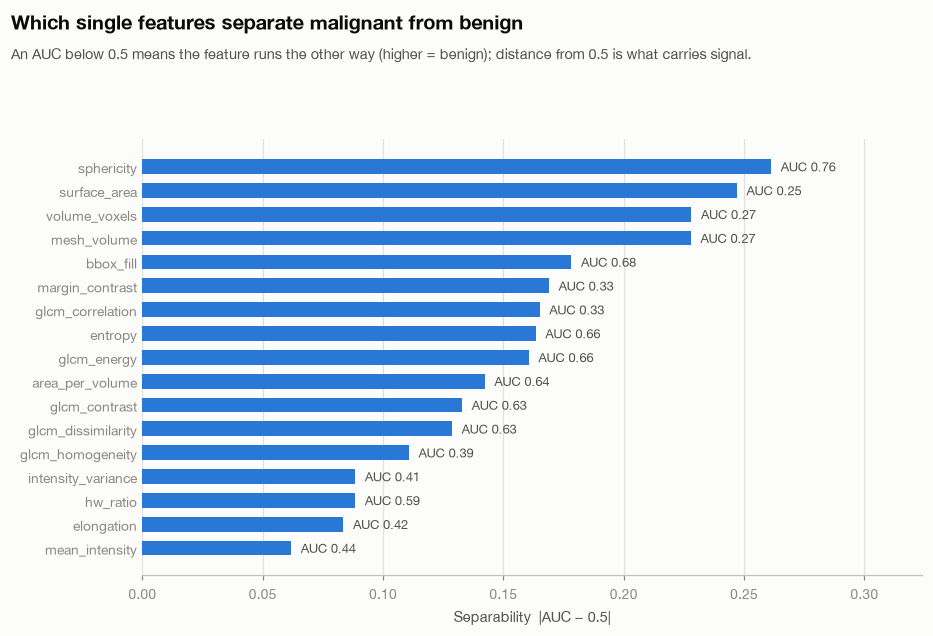

In [15]:
rank = summary.sort_values("|auc-0.5|")
fig, ax = plt.subplots(figsize=(8.5, 6))

y = np.arange(len(rank))
ax.barh(y, rank["|auc-0.5|"], height=0.62, color=BENIGN)
for yi, (v, auc) in enumerate(zip(rank["|auc-0.5|"], rank["auc"])):
    ax.text(v + 0.004, yi, f"AUC {auc:.2f}", va="center", ha="left", fontsize=8.5, color=INK_2)

ax.set_yticks(y, rank["feature"])
ax.set_xlabel("Separability  |AUC − 0.5|")
ax.set_xlim(0, rank["|auc-0.5|"].max() * 1.24)
value_grid(ax, axis="x")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

top = fig_title(fig, "Which single features separate malignant from benign",
                "An AUC below 0.5 means the feature runs the other way (higher = benign); "
                "distance from 0.5 is what carries signal.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### Distributions of the strongest features

Box plots for the six most separable features, malignant against benign.

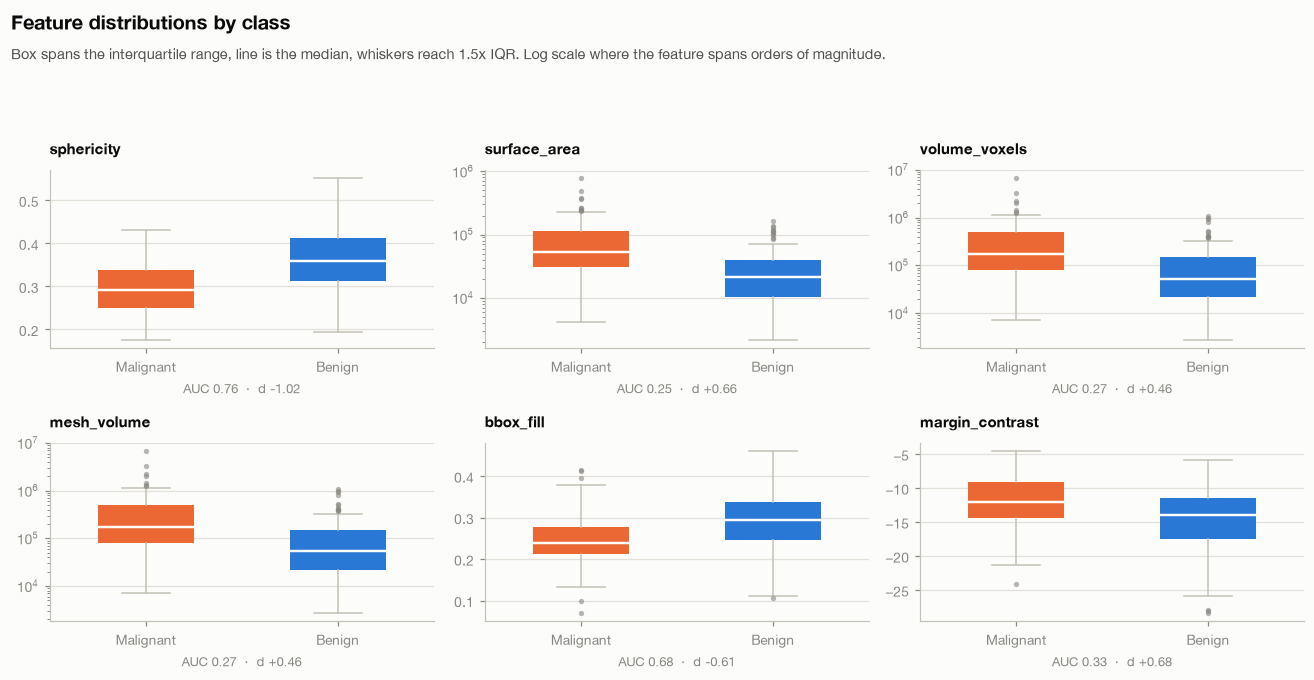

In [16]:
top6 = summary.head(6)["feature"].tolist()
LOG_SCALE = {"volume_voxels", "mesh_volume", "surface_area", "intensity_variance"}

fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, feat in zip(axes.ravel(), top6):
    data = [mal_rows[feat].to_numpy(), ben_rows[feat].to_numpy()]
    bp = ax.boxplot(data, positions=[0, 1], widths=0.5, patch_artist=True,
                    medianprops=dict(color=SURFACE, linewidth=1.6),
                    whiskerprops=dict(color=AXIS, linewidth=1),
                    capprops=dict(color=AXIS, linewidth=1),
                    flierprops=dict(marker="o", markersize=3.5, markerfacecolor=MUTED,
                                    markeredgecolor="none", alpha=0.6))
    for patch, cls in zip(bp["boxes"], (0, 1)):
        patch.set_facecolor(CLASS_COLOR[cls])
        patch.set_edgecolor("none")
    if feat in LOG_SCALE:
        ax.set_yscale("log")
    ax.set_xticks([0, 1], [CLASS_NAME[0], CLASS_NAME[1]])
    row = summary[summary["feature"] == feat].iloc[0]
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel(f"AUC {row['auc']:.2f}  ·  d {row['cohens_d']:+.2f}", fontsize=8.5, color=MUTED)
    value_grid(ax)

top = fig_title(fig, "Feature distributions by class",
                "Box spans the interquartile range, line is the median, whiskers reach 1.5x IQR. "
                "Log scale where the feature spans orders of magnitude.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### Feature correlation

Correlation is a *polarity* scale, so it takes a diverging map: one hue per sign, neutral gray
at zero. Tight blocks of near-1 correlation mean those features are redundant — the size
group especially.

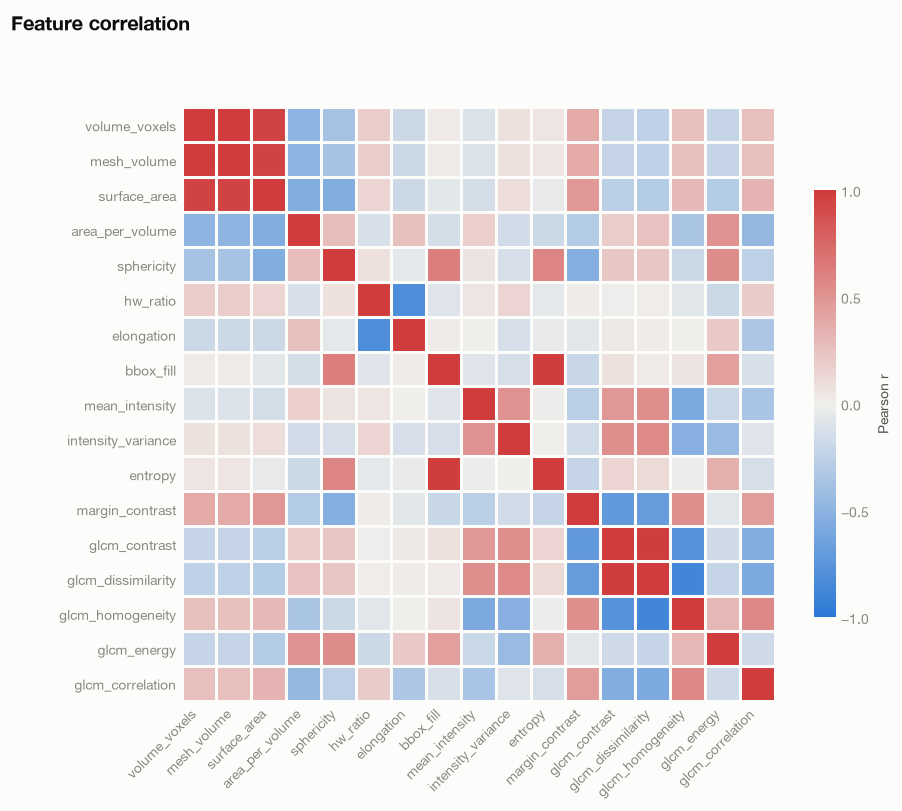

In [17]:
corr = features[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8.6, 7.4))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)), FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLS)), FEATURE_COLS)
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_xticks(np.arange(len(FEATURE_COLS) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(FEATURE_COLS) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.72, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, colors=MUTED)
cbar.set_label("Pearson r", color=INK_2, fontsize=9)

top = fig_title(fig, "Feature correlation")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### The two strongest features together

Where a single feature separates weakly, a pair may do better. This is the raw material a
classifier works with — and a visual check on how much overlap it has to resolve.

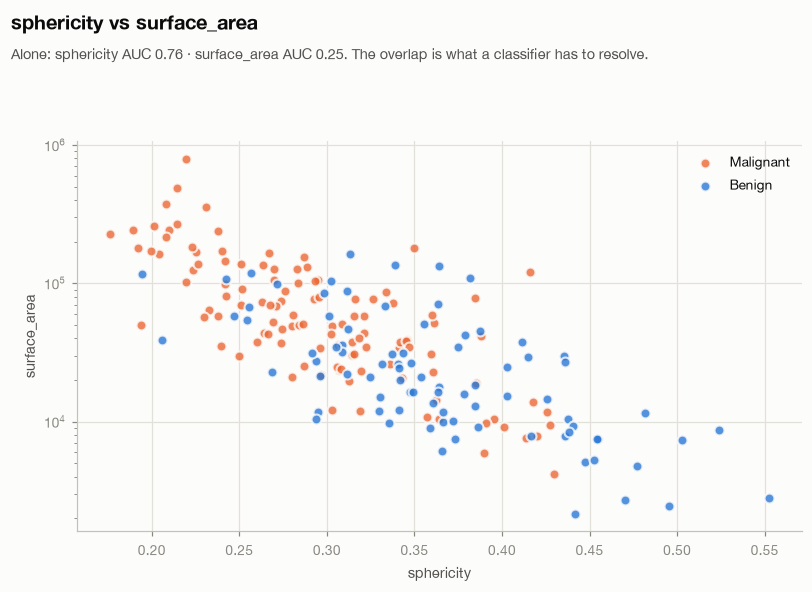

In [18]:
fx, fy = summary.iloc[0]["feature"], summary.iloc[1]["feature"]

fig, ax = plt.subplots(figsize=(7.4, 5.6))
for cls in (0, 1):
    sub = features[features["label"] == cls]
    ax.scatter(sub[fx], sub[fy], s=42, color=CLASS_COLOR[cls], alpha=0.8,
               edgecolor=SURFACE, linewidth=1.4, label=CLASS_NAME[cls], zorder=3)

if fx in LOG_SCALE:
    ax.set_xscale("log")
if fy in LOG_SCALE:
    ax.set_yscale("log")
ax.set_xlabel(fx)
ax.set_ylabel(fy)
value_grid(ax, axis="both")
ax.legend(loc="best")

top = fig_title(fig, f"{fx} vs {fy}",
                f"Alone: {fx} AUC {summary.iloc[0]['auc']:.2f} · "
                f"{fy} AUC {summary.iloc[1]['auc']:.2f}. "
                "The overlap is what a classifier has to resolve.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

## Takeaways

- **The dataset is small and imbalanced.** 200 cases across three splits, malignant-leaning in
  each. With this few cases, a difference of a handful of samples moves accuracy by a full
  percentage point, so report AUC alongside accuracy and prefer cross-validation over a single
  train/test split.
- **Lesions are thin slabs, not blobs.** `len_x` is the shortest bounding-box axis in all 200
  cases, and sphericity sits well below 1 throughout — worth remembering before resampling to
  an isotropic cube, which distorts the axis that carries the most shape information.
- **Mesh-derived features need `pad=2, preprocess=False`.** Either mistake yields an open
  surface and a negative volume, which silently poisons every volume, area and sphericity
  feature built on it — and it fails on exactly the large malignant lesions that matter most.
  A watertight check belongs in any pipeline that meshes these masks.
- **The size features are largely redundant** with one another (see the correlation block);
  pick one, or decorrelate, before feeding them to a linear model.